# Exploratory Data Analysis (EDA)
This notebook covers distributions, correlations, leakage checks, and feature–target analysis.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


## Create Sample Dataset

In [2]:

data = {
    "customer_id": [1, 2, 3, 4, 5, 6, 7, 8],
    "amount": [100, 120, 130, 150, 180, 200, 2500, 3000],
    "category": ["A", "A", "B", "B", "A", "C", "C", "C"],
    "tenure_months": [2, 5, 8, 12, 24, 36, 40, 48],
    "target": [0, 0, 0, 1, 0, 1, 1, 1]
}

df = pd.DataFrame(data)
df


,customer_id,amount,category,tenure_months,target
0,1,100,A,2,0
1,2,120,A,5,0
2,3,130,B,8,0
3,4,150,B,12,1
4,5,180,A,24,0
5,6,200,C,36,1
6,7,2500,C,40,1
7,8,3000,C,48,1


## Data Overview

In [3]:

df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customer_id    8 non-null      int64 
 1   amount         8 non-null      int64 
 2   category       8 non-null      object
 3   tenure_months  8 non-null      int64 
 4   target         8 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 452.0+ bytes


,customer_id,amount,tenure_months,target
count,8.00000,8.000000,8.00000,8.000000
mean,4.50000,797.500000,21.87500,0.500000
std,2.44949,1212.915614,17.66706,0.534522
min,1.00000,100.000000,2.00000,0.000000
25%,2.75000,127.500000,7.25000,0.000000
50%,4.50000,165.000000,18.00000,0.500000
75%,6.25000,775.000000,37.00000,1.000000
max,8.00000,3000.000000,48.00000,1.000000


## Distribution Analysis

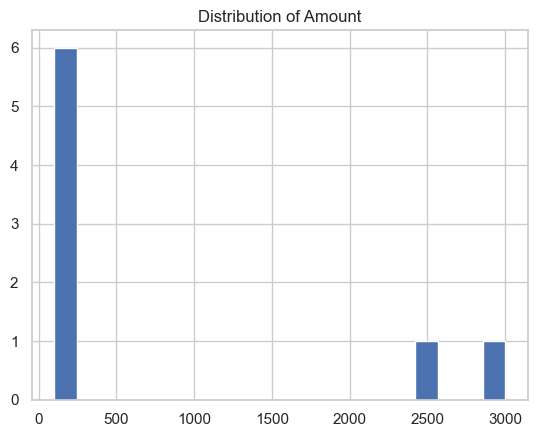

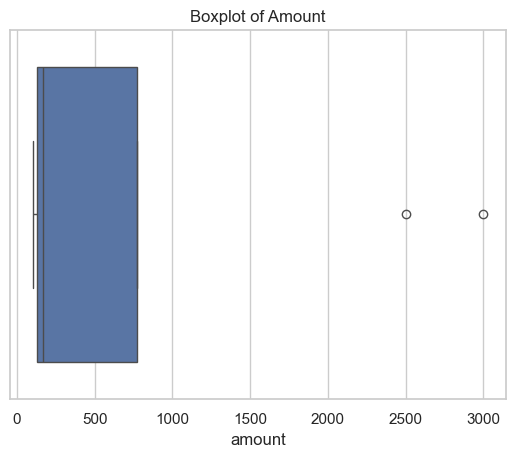

In [4]:

df["amount"].hist(bins=20)
plt.title("Distribution of Amount")
plt.show()

sns.boxplot(x=df["amount"])
plt.title("Boxplot of Amount")
plt.show()


## Categorical Analysis

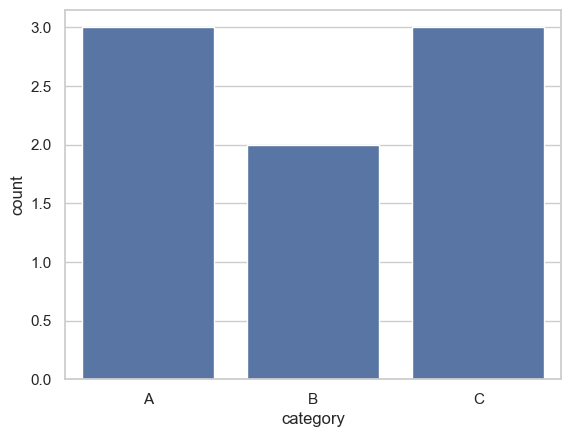

In [5]:

df["category"].value_counts()
(df["category"].value_counts(normalize=True) * 100)

sns.countplot(data=df, x="category")
plt.show()


## Correlation Analysis

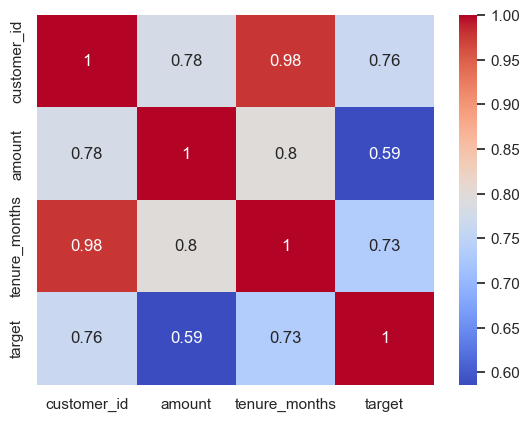

In [6]:

corr = df.corr(numeric_only=True)
corr

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()


## Leakage Check

In [7]:

corr["target"].sort_values(ascending=False)


target           1.000000
customer_id      0.763763
tenure_months    0.733691
amount           0.586121
Name: target, dtype: float64

## Feature vs Target Analysis

In [12]:

df.groupby("target")["amount"].mean()






target
0     132.5
1    1462.5
Name: amount, dtype: float64

In [11]:
pd.crosstab(df["category"], df["target"], normalize="index")

target,0,1
category,,
A,1.0,0.0
B,0.5,0.5
C,0.0,1.0


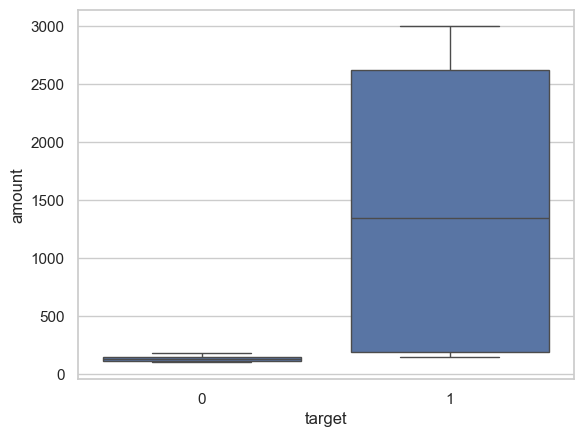

In [10]:
sns.boxplot(data=df, x="target", y="amount")
plt.show()

## Final Notes
EDA helps understand data behavior, detect leakage, and prevent misleading models.